# 03 — M2: Exploratory Respiratory–Acoustic Correlation Analysis

**Pipeline stage:** Milestone&nbsp;2 — does anything in the voice covary with the breathing signal?

**Script this notebook reproduces:** `scripts/m2_correlation.py` (all seven analysis *levels*).
We import the script's own computation helpers so the numbers match exactly, and render every
figure inline instead of writing PDFs.

| Level | Question | Plot type(s) |
|-------|----------|--------------|
| 1 — Global | Do per-segment summaries correlate across the cohort? | correlation heatmap, scatter grid, within-segment histograms |
| 2 — Time-resolved | Does coupling fluctuate within a recording? | dual-axis + sliding-r panel, aggregate histogram |
| 3 — FRC event | Do features shift across the FRC crossing? | shift histograms, above-vs-below paired scatter |
| 4 — Sex-stratified | Are correlations different by sex? | side-by-side heatmaps, sex-coloured scatter |
| 5 — Lag | Does flow lead the acoustics? | mean cross-correlation curve, peak-lag histogram |
| 6 — Breath group | How do features evolve across a read text? | evolution scatter + binned means, correlation heatmap |
| 7 — MFCC | Does spectral shape track respiration? | MFCC×OEP heatmap, per-coefficient boxplots |

> **Key observations (corrected cohort).** After the OEP sample-rate fix (≈⅓ of recordings were 100 Hz read as 50 Hz, time-stretching the OEP), the cross-domain correlations are coherent and the previously-*inflated* flow correlations (a 2× time-stretch artifact) are gone — the corrected 100 Hz subjects now match the never-affected 50 Hz reference. Honest picture: in **steady phonation the coupling is modest** — energy↔chest-wall-volume ≈ **+0.24** (strongest; a touch higher in elderly males), spectral-centroid↔volume ≈ +0.15, acoustic↔**flow ≈ 0**. The one **strong** coupling — **f0↔volume ≈ −0.88, 100 % sign-consistent** — appears only in the **vocal glide `a_7`** (active pitch modulation). Take-away: voice tracks lung **volume (position)**, not **flow (rate)**; strong coupling needs a task that modulates the feature. Stratified breakdown + the FRC example are in **nb04**.

## 0. Setup
The analysis scripts force the non-interactive `Agg` backend on import; we restore the inline backend afterwards so figures render in the notebook.

In [1]:

import sys
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

REPO = Path.cwd()
while not (REPO / "pneumophonic_analysis").exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))
sys.path.insert(0, str(REPO / "scripts"))

from pneumophonic_analysis.paired_features import PairedFeatureExtractor
# Import the real M2 helpers (keeps the notebook in sync with the script)
import m2_correlation as m2
from analyze_l3_stratified import find_frc_crossing_index

# m2_correlation forced the Agg backend on import; the magic below restores inline rendering
%matplotlib inline
sns.set_theme(style="whitegrid", font_scale=1.0)
plt.rcParams["figure.dpi"] = 110

PAIRED_DIR = REPO / "data_target" / "healthy_subjects" / "paired"
h5_files = sorted(PAIRED_DIR.glob("*.h5"))
print(f"{len(h5_files)} paired recordings | SUSTAINED={sorted(m2.SUSTAINED_TASKS)} | SPEECH={sorted(m2.SPEECH_TASKS)}")

550 paired recordings | SUSTAINED=['a', 'a_2', 'a_3', 'a_7', 'r'] | SPEECH=['f_1', 'f_2', 'f_3', 'f_4', 'f_5', 'testo']


## Level 1 — Global per-segment correlations
Each recording is reduced to summary statistics (`m2.compute_segment_summary`); we then correlate
those summaries *across* the cohort.

In [2]:

summaries = []
for h5 in h5_files:
    try:
        df, meta = PairedFeatureExtractor.load_hdf5(h5)
        summaries.append(m2.compute_segment_summary(df, meta))
    except Exception as e:
        pass
summary_df = pd.DataFrame(summaries)
print(f"{len(summary_df)} segments from {summary_df['subject_id'].nunique()} subjects")
summary_df[['subject_id','task','f0_mean','energy_mean','flow_cw_mean','pct_rc_mean','delta_vcw_range']].head()

550 segments from 39 subjects


,subject_id,task,f0_mean,energy_mean,flow_cw_mean,pct_rc_mean,delta_vcw_range
0,AlMo,a,111.807687,0.020785,-0.196472,0.721357,0.935251
1,AlMo,a_2,108.007273,0.005885,-0.193257,0.727348,3.424967
2,AlMo,a_7,153.268783,0.048470,-0.392663,0.701125,0.747703
3,AlMo,e,112.839995,0.016854,-0.205788,0.723938,0.894628
4,AlMo,f_1,130.441985,0.154071,-0.362479,0.708394,0.258248


### 1a. Cross-subject correlation heatmap (audio × OEP summaries)

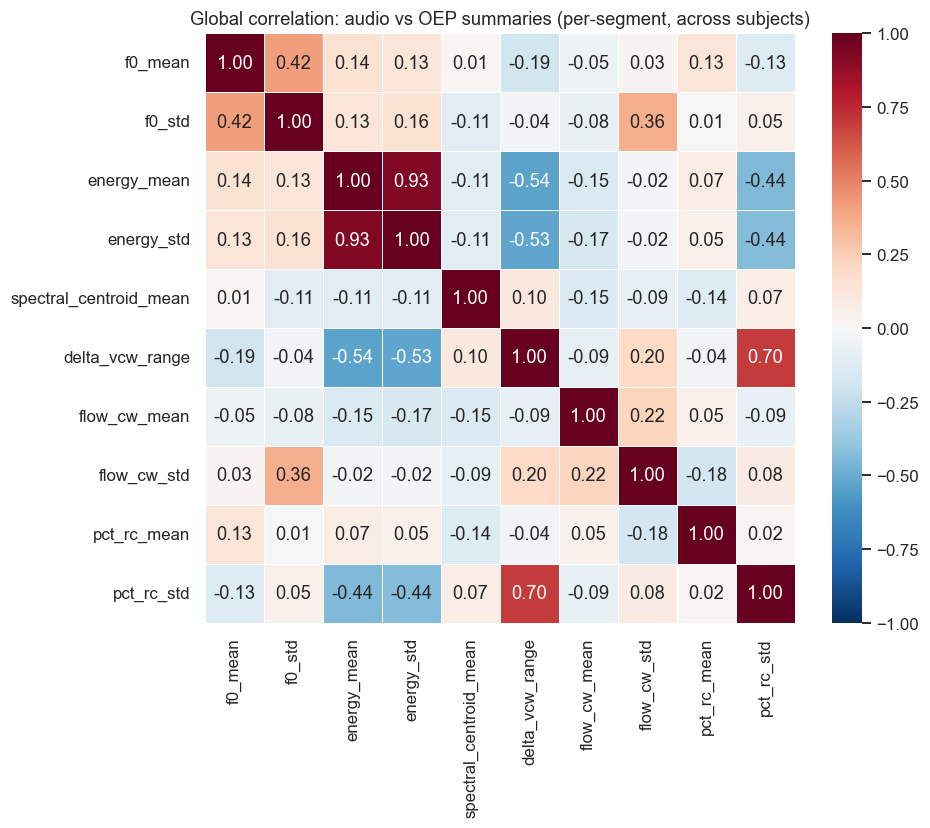

In [3]:

audio_cols = ['f0_mean', 'f0_std', 'energy_mean', 'energy_std', 'spectral_centroid_mean']
oep_cols   = ['delta_vcw_range', 'flow_cw_mean', 'flow_cw_std', 'pct_rc_mean', 'pct_rc_std']
avail = [c for c in audio_cols + oep_cols if c in summary_df.columns]
corr_data = summary_df[avail].dropna()

fig, ax = plt.subplots(figsize=(9, 7.5))
sns.heatmap(corr_data.corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Global correlation: audio vs OEP summaries (per-segment, across subjects)')
plt.tight_layout(); plt.show()

> **Observe:** between subjects, audio summaries show only weak-to-moderate correlation with OEP summaries; the strongest cells involve `energy_mean` × `delta_vcw_range` (loudness ↔ volume excursion). No audio feature is a strong linear proxy for a respiratory summary across subjects.

### 1b. Key scatter relationships (coloured by task family)

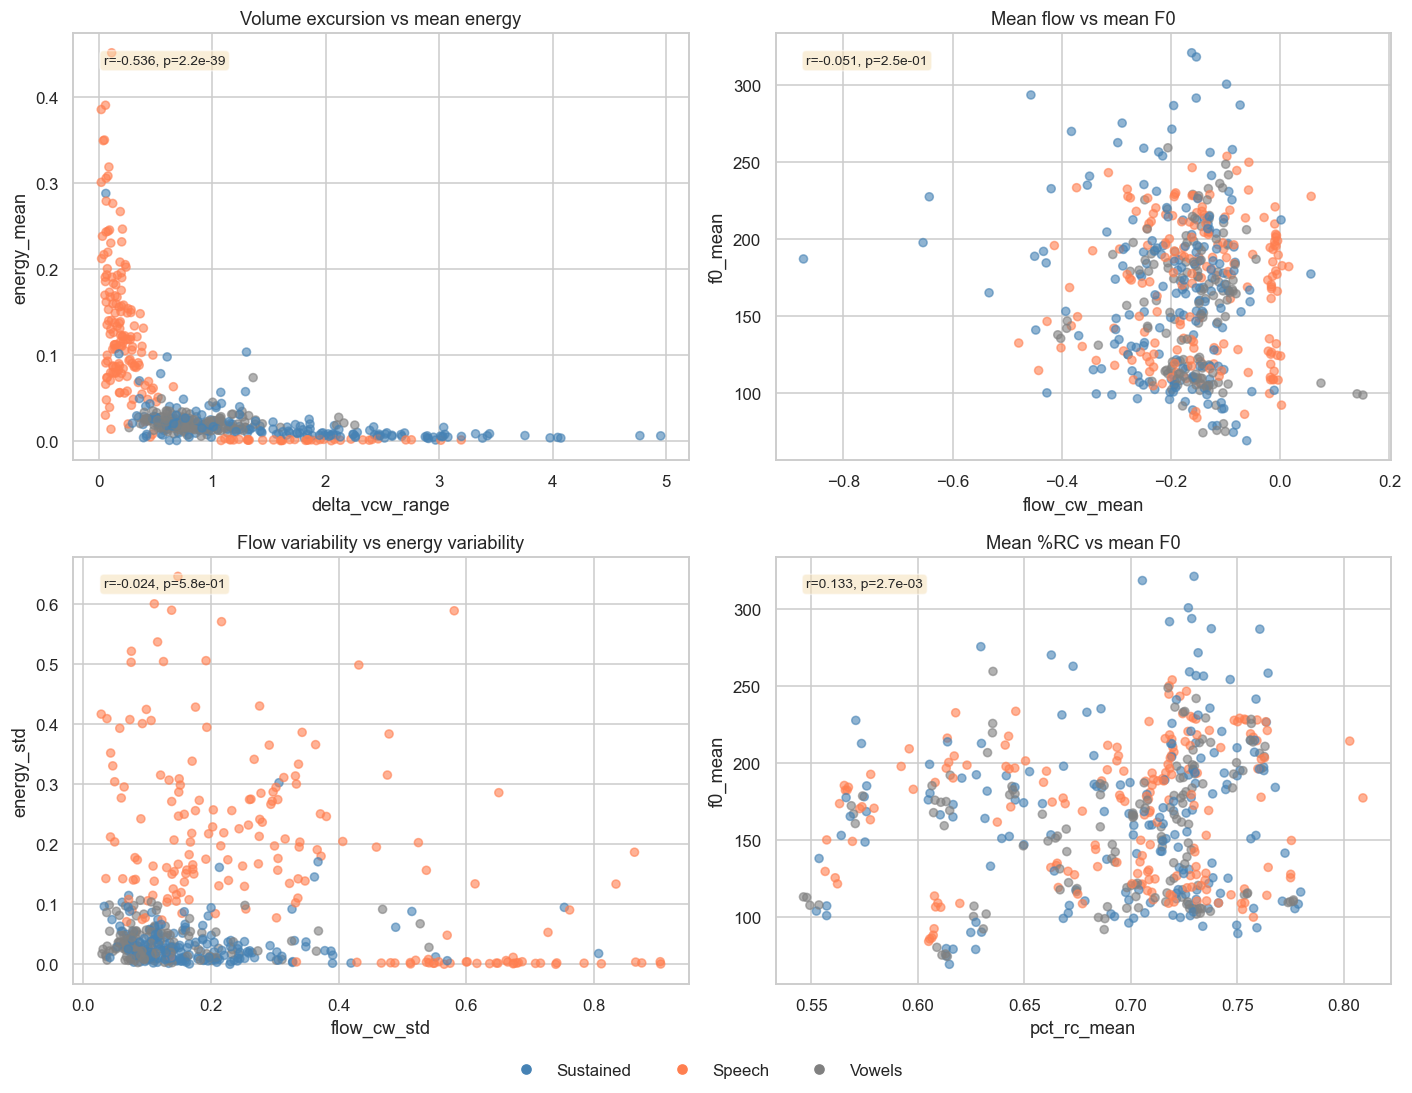

In [4]:

pairs = [('delta_vcw_range','energy_mean','Volume excursion vs mean energy'),
         ('flow_cw_mean','f0_mean','Mean flow vs mean F0'),
         ('flow_cw_std','energy_std','Flow variability vs energy variability'),
         ('pct_rc_mean','f0_mean','Mean %RC vs mean F0')]
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for ax, (x, y, title) in zip(axes.flat, pairs):
    v = summary_df[[x, y, 'task']].dropna()
    colors = ['steelblue' if t in m2.SUSTAINED_TASKS else 'coral' if t in m2.SPEECH_TASKS else 'gray'
              for t in v['task']]
    ax.scatter(v[x], v[y], c=colors, alpha=0.6, s=28)
    r, p = stats.pearsonr(v[x], v[y])
    ax.set_xlabel(x); ax.set_ylabel(y); ax.set_title(title)
    ax.annotate(f'r={r:.3f}, p={p:.1e}', xy=(0.05, 0.95), xycoords='axes fraction',
                va='top', fontsize=9, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
from matplotlib.lines import Line2D
fig.legend(handles=[Line2D([0],[0],marker='o',color='w',markerfacecolor=c,label=l,markersize=8)
                    for c,l in [('steelblue','Sustained'),('coral','Speech'),('gray','Vowels')]],
           loc='lower center', ncol=3)
plt.tight_layout(rect=[0, 0.03, 1, 1]); plt.show()

> **Observe:** the clearest trend is volume-excursion ↔ loudness (bigger `ΔVcw` span → louder), but the cloud is broad and splits by task family (sustained vs speech). The link is real but modest; subject identity explains much of the spread.

### 1c. Distribution of within-segment correlations
For each recording we already stored the internal Pearson r between coupled signals; here is their distribution across the cohort.

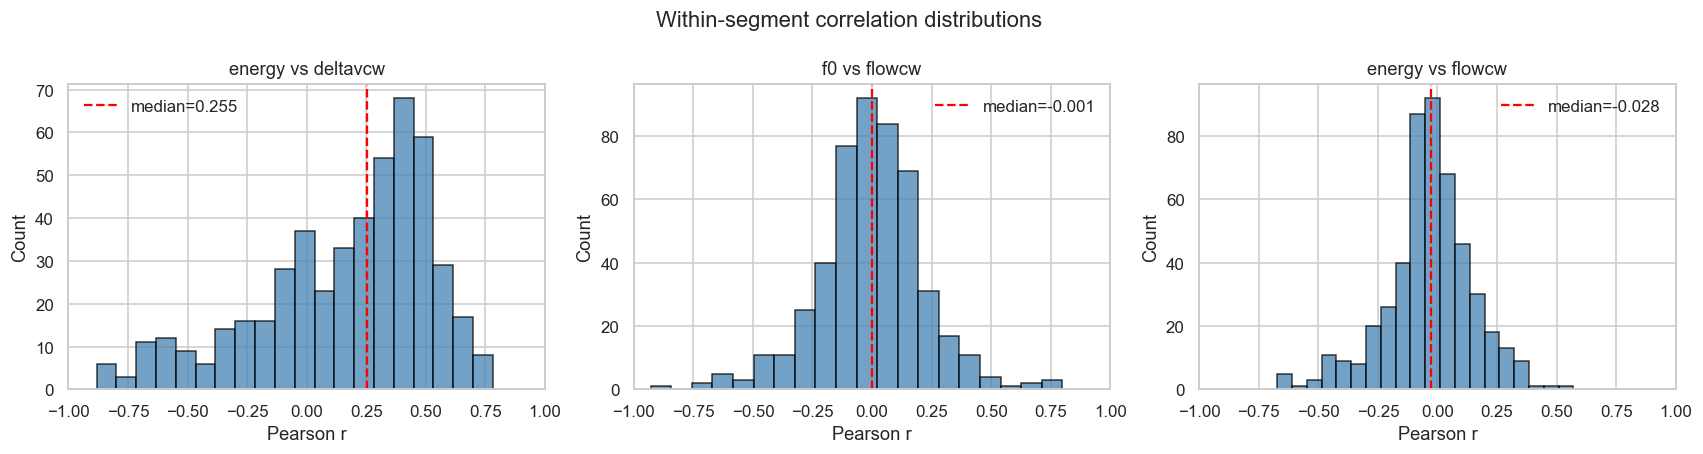

In [5]:

within = ['corr_energy_deltavcw', 'corr_f0_flowcw', 'corr_energy_flowcw']
within = [c for c in within if c in summary_df.columns]
fig, axes = plt.subplots(1, len(within), figsize=(5.2*len(within), 4.2))
for ax, col in zip(np.atleast_1d(axes), within):
    d = summary_df[col].dropna()
    ax.hist(d, bins=20, color='steelblue', alpha=0.75, edgecolor='black')
    ax.axvline(d.median(), color='red', ls='--', label=f'median={d.median():.3f}')
    ax.set_xlim(-1, 1); ax.set_xlabel('Pearson r'); ax.set_ylabel('Count')
    ax.set_title(col.replace('corr_', '').replace('_', ' vs ')); ax.legend()
plt.suptitle('Within-segment correlation distributions'); plt.tight_layout(); plt.show()

> **Observe:** within-recording correlation distributions sit modestly off zero — `energy↔ΔVcw` positive (loudness tracks volume), `f0↔flow`/`energy↔flow` near zero. After the rate fix these are coherent; the previously-*inflated* flow correlations (desync artifact) are gone.

## Level 2 — Time-resolved coupling
Sliding-window Pearson correlation (`m2.compute_sliding_correlation`, 0.5&nbsp;s window) between
audio energy and `ΔVcw` inside one sustained recording.

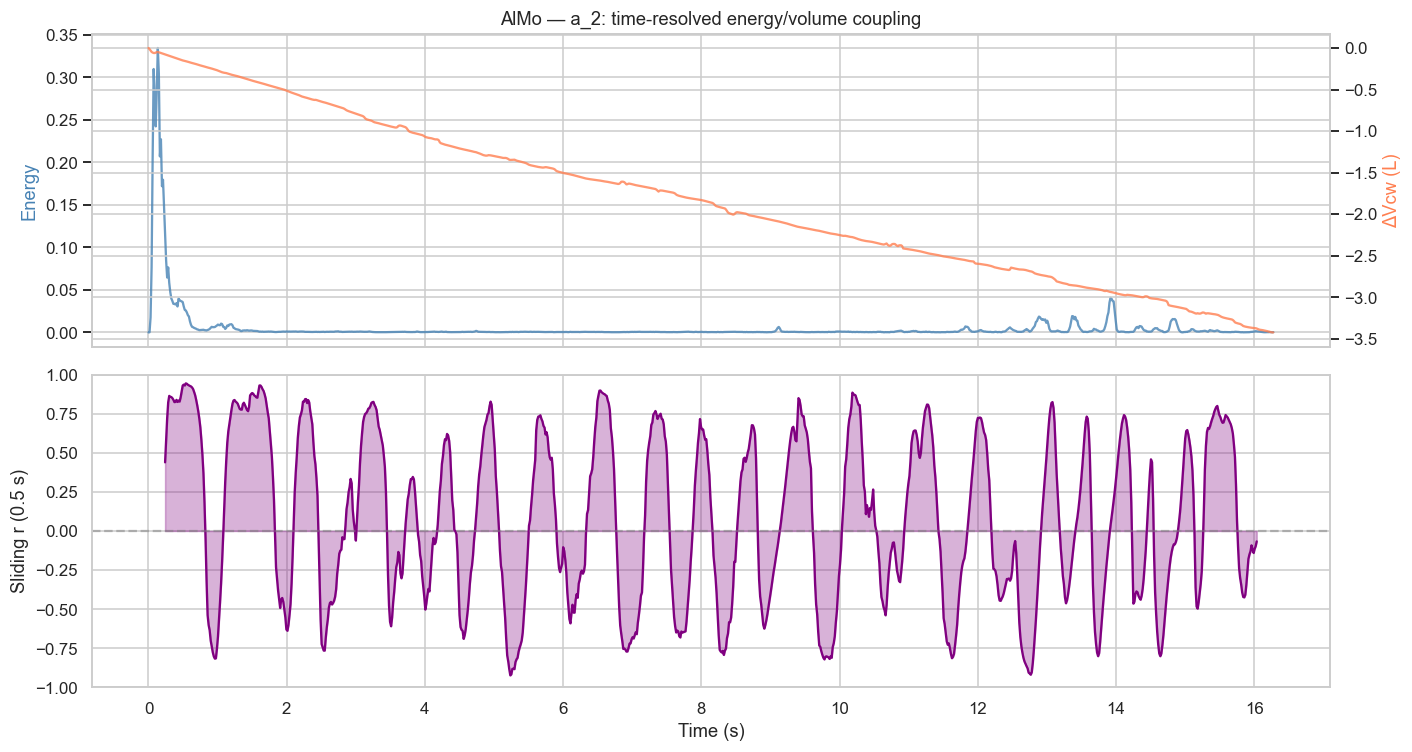

In [6]:

ex = next(h for h in h5_files if h.stem.endswith('_a_2'))
df, meta = PairedFeatureExtractor.load_hdf5(ex)
r_ev = m2.compute_sliding_correlation(df['energy'].values, df['delta_vcw'].values, window_frames=33)

fig, (a1, a2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
a1.plot(df['time'], df['energy'], color='steelblue', alpha=0.8, label='Energy')
a1b = a1.twinx(); a1b.plot(df['time'], df['delta_vcw'], color='coral', alpha=0.8, label='ΔVcw')
a1.set_ylabel('Energy', color='steelblue'); a1b.set_ylabel('ΔVcw (L)', color='coral')
a1.set_title(f"{meta['subject_id']} — {meta['task_name']}: time-resolved energy/volume coupling")
a2.plot(df['time'], r_ev, color='purple', lw=1.5)
a2.fill_between(df['time'], r_ev, 0, where=~np.isnan(r_ev), alpha=0.3, color='purple')
a2.axhline(0, color='gray', ls='--', alpha=0.5); a2.set_ylim(-1, 1)
a2.set_ylabel('Sliding r (0.5 s)'); a2.set_xlabel('Time (s)')
plt.tight_layout(); plt.show()

> **Observe:** the sliding-window correlation wanders across the recording — coupling is **not stationary**; it strengthens and weakens within one phonation, so a single segment-level *r* hides this.

### 2b. Aggregate distribution of mean sliding-r (sustained tasks)

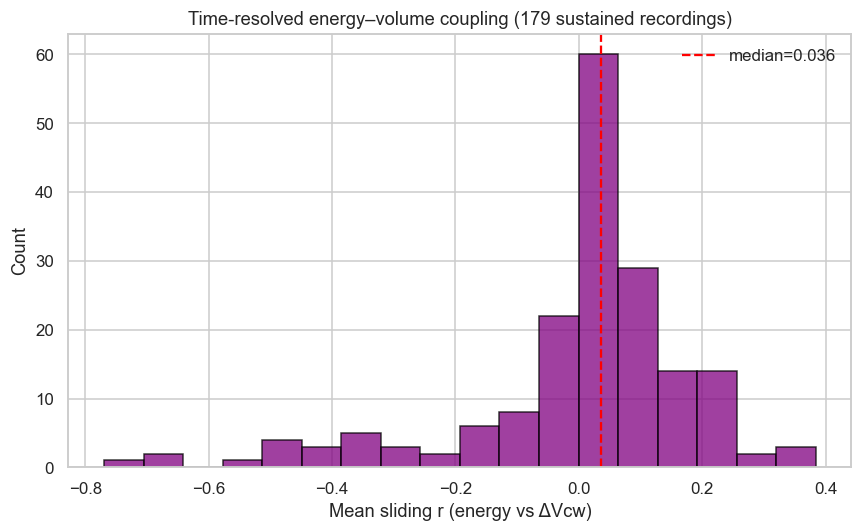

In [7]:

mean_rs = []
sus = [h for h in h5_files if any(h.stem.endswith('_'+t) for t in m2.SUSTAINED_TASKS)]
for h5 in sus:
    df, meta = PairedFeatureExtractor.load_hdf5(h5)
    if len(df) < 100: continue
    r = m2.compute_sliding_correlation(df['energy'].values, df['delta_vcw'].values, 33)
    mean_rs.append(np.nanmean(r))
mean_rs = np.array([x for x in mean_rs if np.isfinite(x)])
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(mean_rs, bins=18, color='purple', alpha=0.75, edgecolor='black')
ax.axvline(np.median(mean_rs), color='red', ls='--', label=f'median={np.median(mean_rs):.3f}')
ax.set_xlabel('Mean sliding r (energy vs ΔVcw)'); ax.set_ylabel('Count')
ax.set_title(f'Time-resolved energy–volume coupling ({len(mean_rs)} sustained recordings)')
ax.legend(); plt.tight_layout(); plt.show()

> **Observe:** pooled mean sliding-*r* over sustained recordings straddles zero with a modest positive lean — weak, variable instantaneous coupling rather than a fixed strong relationship.

## Level 3 — FRC-crossing event analysis
For maximum-phonation tasks we split each recording at the FRC crossing and compare audio features
**above** vs **below** FRC (the same detector used in notebook 04).

In [8]:

FRC_TASKS = {'a_2', 'a_3', 'a_7'}
rows = []
for h5 in h5_files:
    df, meta = PairedFeatureExtractor.load_hdf5(h5)
    if meta.get('task_name') not in FRC_TASKS: continue
    cross = find_frc_crossing_index(df['delta_vcw'].values)
    if cross is None: continue
    above, below = df.iloc[:cross], df.iloc[cross:]
    av, bv = above[above['voiced']==1.0], below[below['voiced']==1.0]
    if len(av) < 10 or len(bv) < 10: continue
    rows.append(dict(
        f0_above=np.nanmean(av['f0']), f0_below=np.nanmean(bv['f0']),
        energy_above=av['energy'].mean(), energy_below=bv['energy'].mean(),
        pct_rc_above=above['pct_rc'].mean(), pct_rc_below=below['pct_rc'].mean(),
        flow_above=above['flow_cw'].mean(), flow_below=below['flow_cw'].mean()))
frc = pd.DataFrame(rows)
for f in ['f0','energy','pct_rc','flow']:
    frc[f+'_shift'] = frc[f+'_below'] - frc[f+'_above']
print(f"{len(frc)} FRC segments")

79 FRC segments


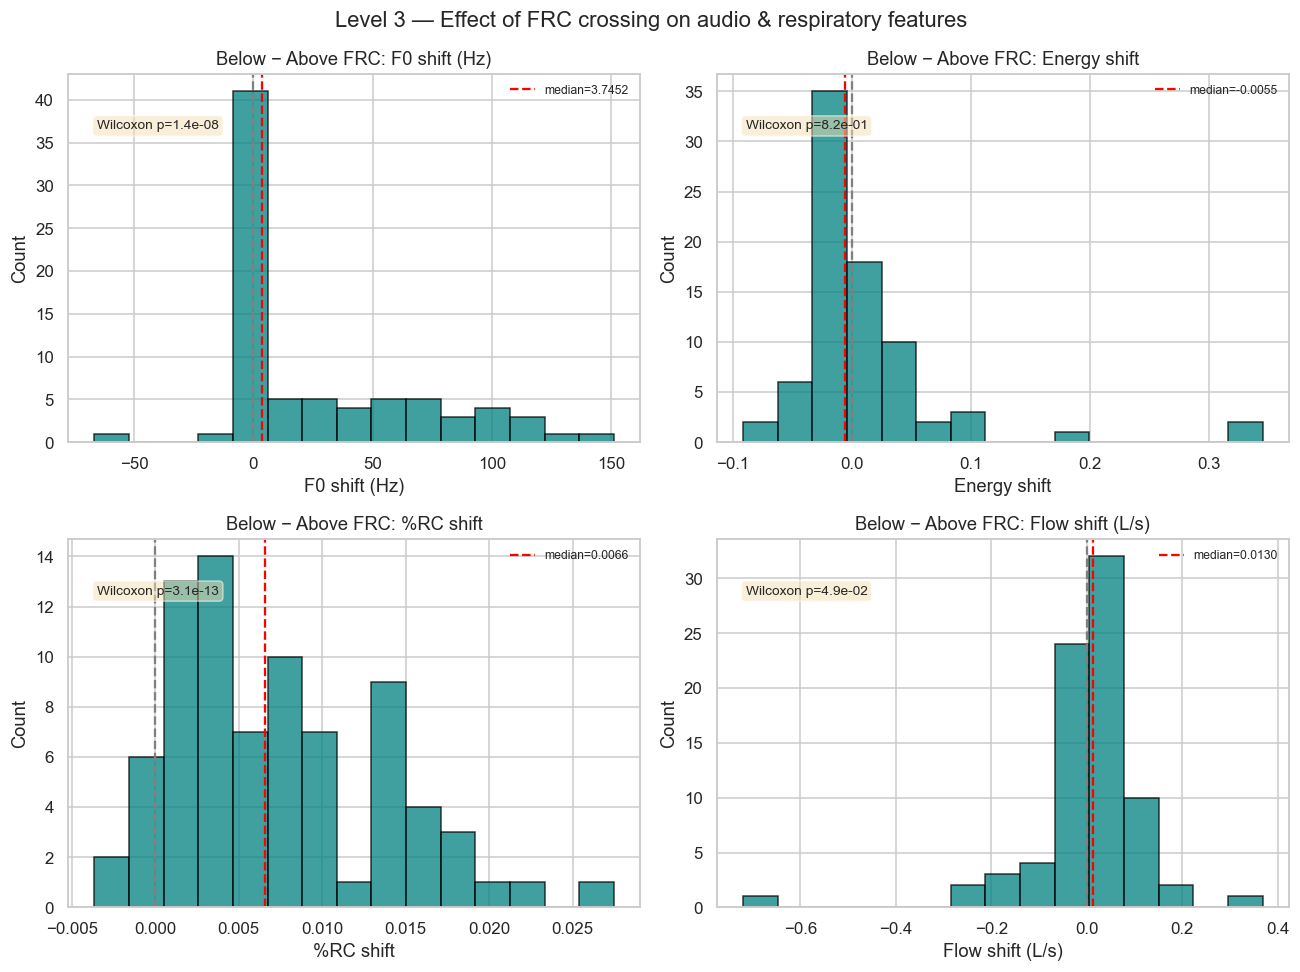

In [9]:

specs = [('f0_shift','F0 shift (Hz)'), ('energy_shift','Energy shift'),
         ('pct_rc_shift','%RC shift'), ('flow_shift','Flow shift (L/s)')]
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, (col, lab) in zip(axes.flat, specs):
    d = frc[col].dropna()
    ax.hist(d, bins=15, color='teal', alpha=0.75, edgecolor='black')
    ax.axvline(0, color='gray', ls='--'); ax.axvline(d.median(), color='red', ls='--',
              label=f'median={d.median():.4f}')
    ax.set_xlabel(lab); ax.set_ylabel('Count'); ax.set_title(f'Below − Above FRC: {lab}')
    try:
        _, p = stats.wilcoxon(d); ax.annotate(f'Wilcoxon p={p:.1e}', xy=(0.05,0.85),
            xycoords='axes fraction', fontsize=9, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    except Exception: pass
    ax.legend(fontsize=8)
plt.suptitle('Level 3 — Effect of FRC crossing on audio & respiratory features'); plt.tight_layout(); plt.show()

> **Observe:** at the FRC crossing, `f0` and `%RC` shift in a consistent direction (medians off zero) while `energy`/`flow` shifts are smaller and noisier. `%RC` is the most consistent shifter — the rib cage re-weights as the lung empties. Genuine-FRC effect sizes are in nb04 (f0 *d*=0.60, %RC *d*=1.17).

### 3b. Above-vs-below paired scatter (identity line)

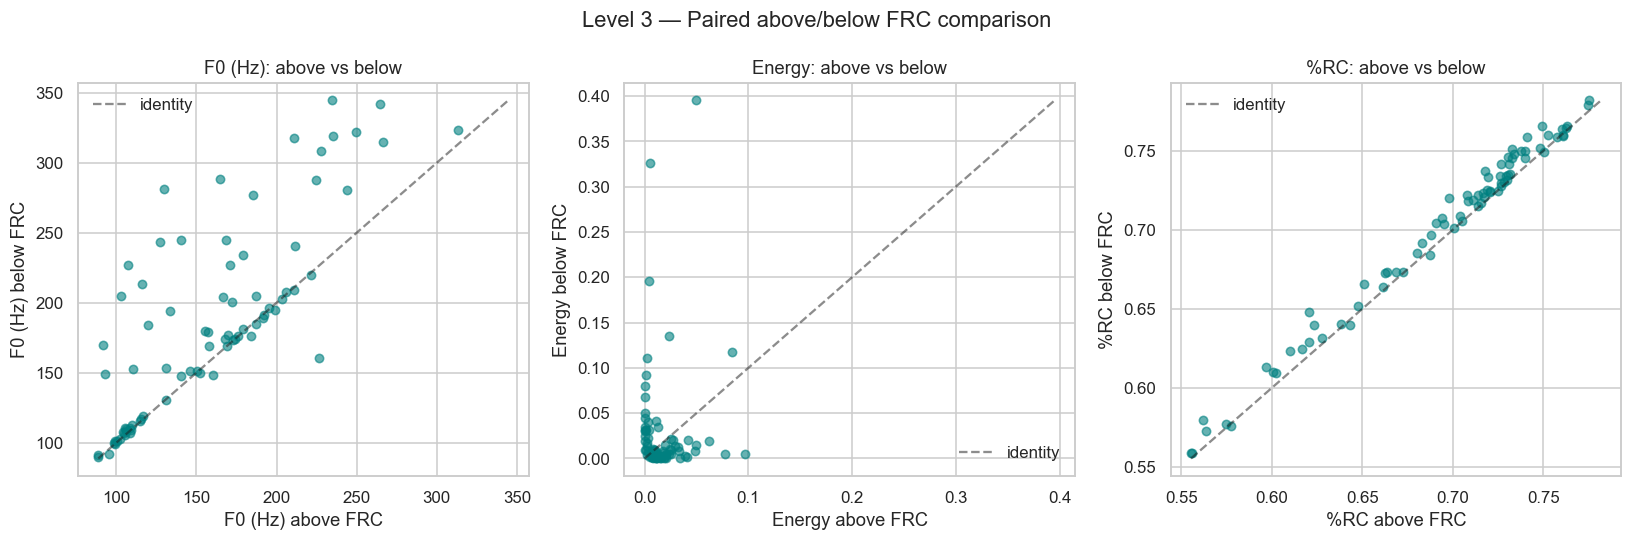

In [10]:

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (a, b, lab) in zip(axes, [('f0_above','f0_below','F0 (Hz)'),
                                  ('energy_above','energy_below','Energy'),
                                  ('pct_rc_above','pct_rc_below','%RC')]):
    v = frc[[a, b]].dropna()
    ax.scatter(v[a], v[b], alpha=0.6, s=30, color='teal')
    lim = [min(v[a].min(), v[b].min()), max(v[a].max(), v[b].max())]
    ax.plot(lim, lim, 'k--', alpha=0.5, label='identity')
    ax.set_xlabel(f'{lab} above FRC'); ax.set_ylabel(f'{lab} below FRC')
    ax.set_title(f'{lab}: above vs below'); ax.legend()
plt.suptitle('Level 3 — Paired above/below FRC comparison'); plt.tight_layout(); plt.show()

> **Observe:** points sit off the identity line in a consistent direction (e.g. F0 higher below FRC), so the shift is **systematic**, not scatter; the spread within each panel is between-subject variability.

## Level 4 — Sex-stratified correlations
Merge subject sex from `subjects_metadata.csv` and recompute the global heatmap separately for each
sex, then overlay sex-coloured scatter.

Male segments=242  Female segments=255


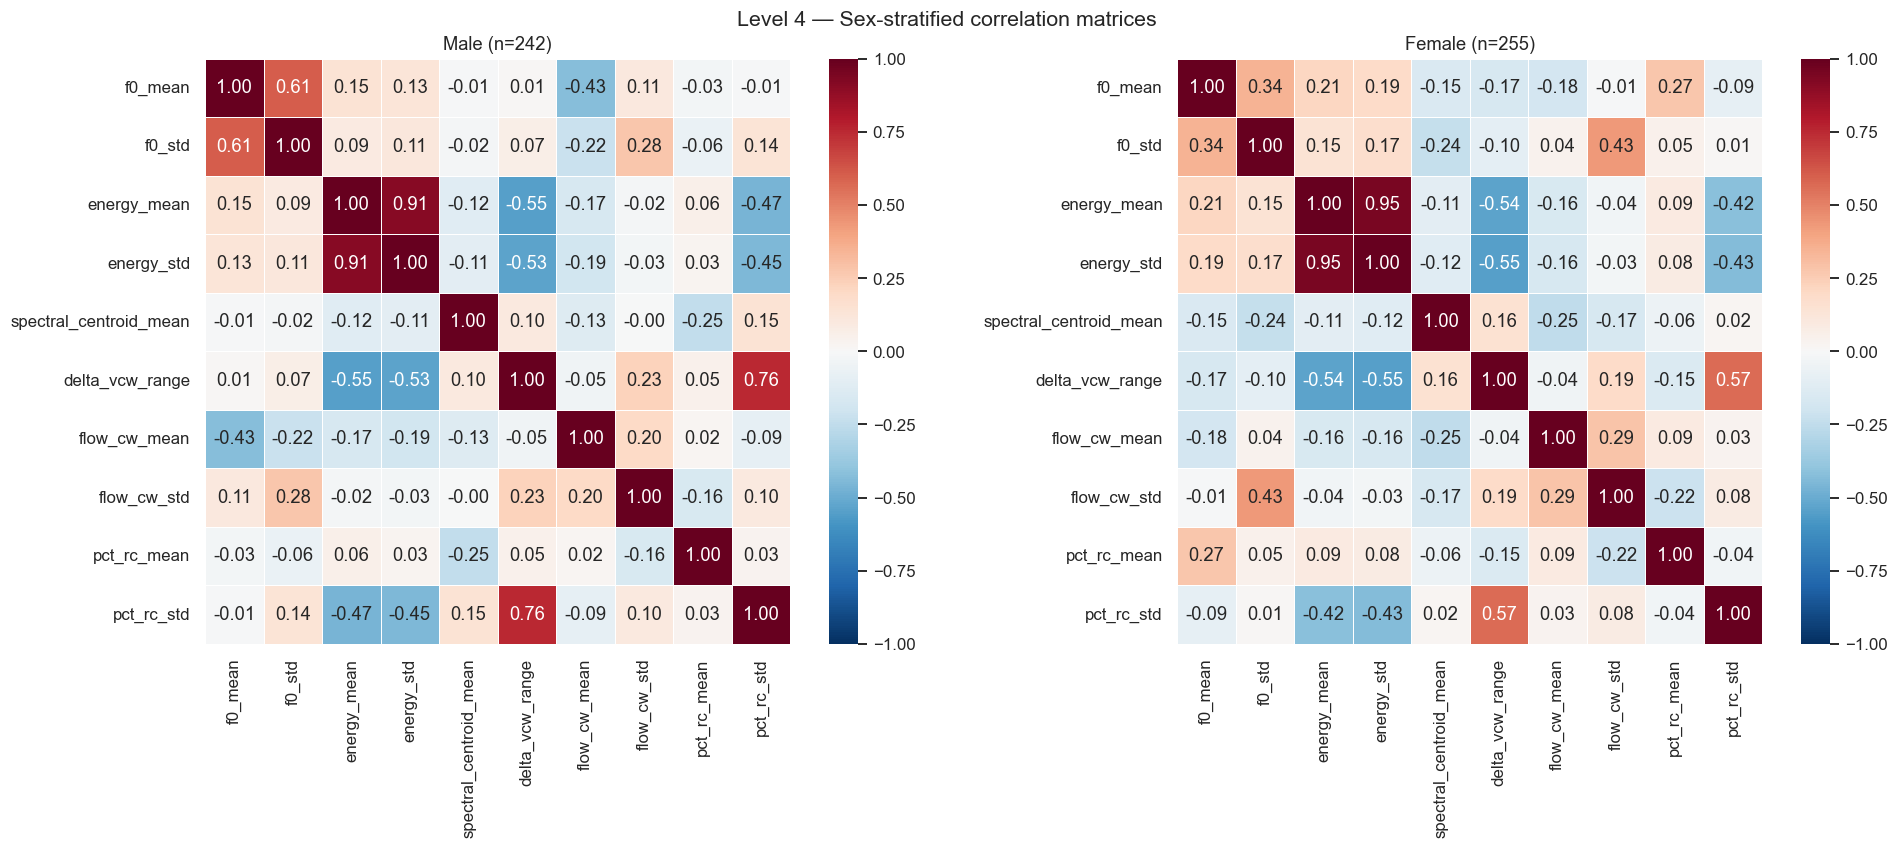

In [11]:

meta_df = m2.load_subject_metadata('healthy_subjects')
merged = summary_df.merge(meta_df, on='subject_id', how='left').dropna(subset=['sex'])
males = merged[merged['sex']=='M'][avail].dropna()
females = merged[merged['sex']=='F'][avail].dropna()
print(f"Male segments={len(males)}  Female segments={len(females)}")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(18, 7.5))
sns.heatmap(males.corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=a1); a1.set_title(f'Male (n={len(males)})')
sns.heatmap(females.corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=a2); a2.set_title(f'Female (n={len(females)})')
plt.suptitle('Level 4 — Sex-stratified correlation matrices', fontsize=14); plt.tight_layout(); plt.show()

> **Observe:** the correlation structure is broadly similar in males and females — modest magnitude differences, no sign flips. Sex alone does not reorganise the coupling (age matters more — nb04).

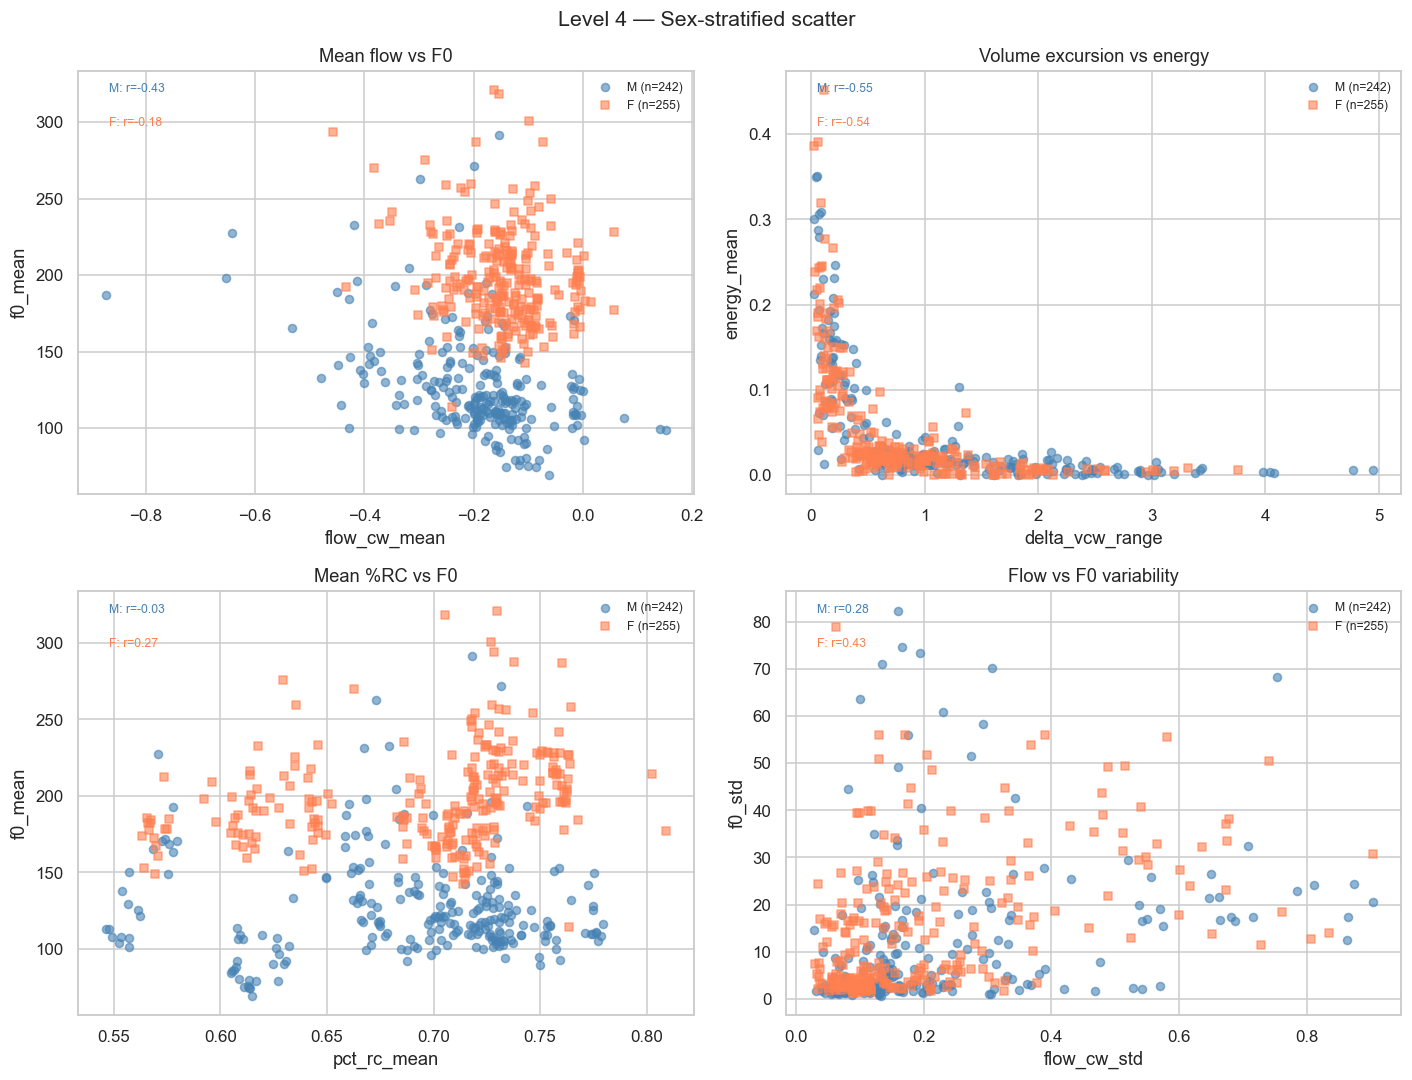

In [12]:

pairs = [('flow_cw_mean','f0_mean','Mean flow vs F0'),
         ('delta_vcw_range','energy_mean','Volume excursion vs energy'),
         ('pct_rc_mean','f0_mean','Mean %RC vs F0'),
         ('flow_cw_std','f0_std','Flow vs F0 variability')]
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for ax, (x, y, title) in zip(axes.flat, pairs):
    for sex, c, mk in [('M','steelblue','o'), ('F','coral','s')]:
        s = merged[(merged['sex']==sex) & merged[x].notna() & merged[y].notna()]
        ax.scatter(s[x], s[y], c=c, marker=mk, alpha=0.6, s=28, label=f'{sex} (n={len(s)})')
        if len(s) > 10:
            r, p = stats.pearsonr(s[x], s[y])
            ax.annotate(f'{sex}: r={r:.2f}', xy=(0.05, 0.95-0.08*(sex=='F')),
                        xycoords='axes fraction', color=c, fontsize=8)
    ax.set_xlabel(x); ax.set_ylabel(y); ax.set_title(title); ax.legend(fontsize=8)
plt.suptitle('Level 4 — Sex-stratified scatter', fontsize=14); plt.tight_layout(); plt.show()

> **Observe:** the flow↔F0 (and related) scatters overlap heavily across sexes; any separation is small relative to within-group spread.

## Level 5 — Cross-correlation with time lags
`m2.compute_xcorr_lag` finds the lag (±0.5&nbsp;s) at which chest-wall flow best predicts energy and
F0. Negative lag = flow *leads* the acoustic signal.

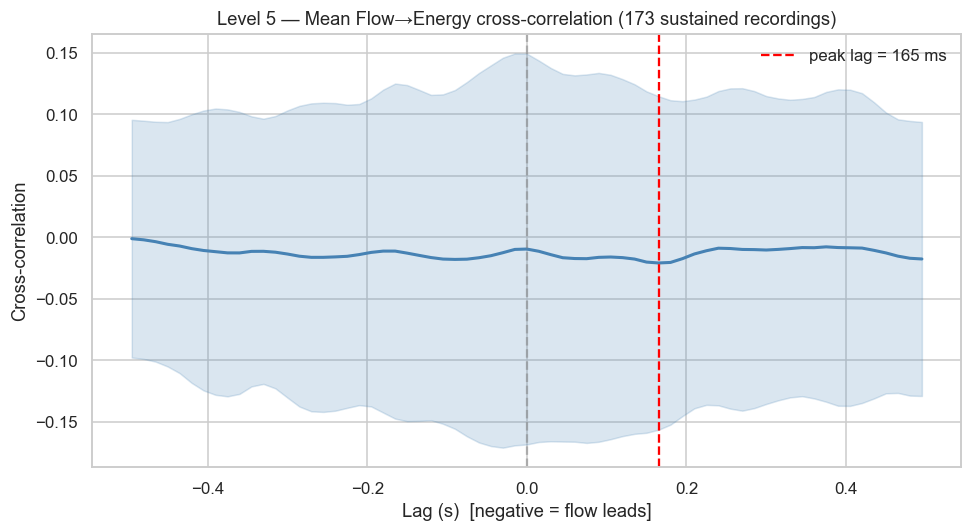

In [13]:

fps, max_lag = 66.67, 33
xc_fe, lags_fe = [], None
for h5 in sus:
    df, meta = PairedFeatureExtractor.load_hdf5(h5)
    v = df[df['voiced']==1.0]
    if len(v) < 50: continue
    lags, xc, _, _ = m2.compute_xcorr_lag(v['flow_cw'].values, v['energy'].values, max_lag, fps)
    if xc is not None:
        xc_fe.append(xc); lags_fe = lags
xc_fe = np.array(xc_fe)
mean_xc, std_xc = xc_fe.mean(0), xc_fe.std(0)
peak = lags_fe[np.argmax(np.abs(mean_xc))]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(lags_fe, mean_xc, color='steelblue', lw=2)
ax.fill_between(lags_fe, mean_xc-std_xc, mean_xc+std_xc, alpha=0.2, color='steelblue')
ax.axvline(0, color='gray', ls='--', alpha=0.5)
ax.axvline(peak, color='red', ls='--', label=f'peak lag = {peak*1000:.0f} ms')
ax.set_xlabel('Lag (s)  [negative = flow leads]'); ax.set_ylabel('Cross-correlation')
ax.set_title(f'Level 5 — Mean Flow→Energy cross-correlation ({len(xc_fe)} sustained recordings)')
ax.legend(); plt.tight_layout(); plt.show()

> **Observe:** the lagged cross-correlation peaks **near zero lag** — no consistent lead/lag between acoustic and respiratory signals at the frame scale; they co-vary roughly instantaneously, when they co-vary at all.

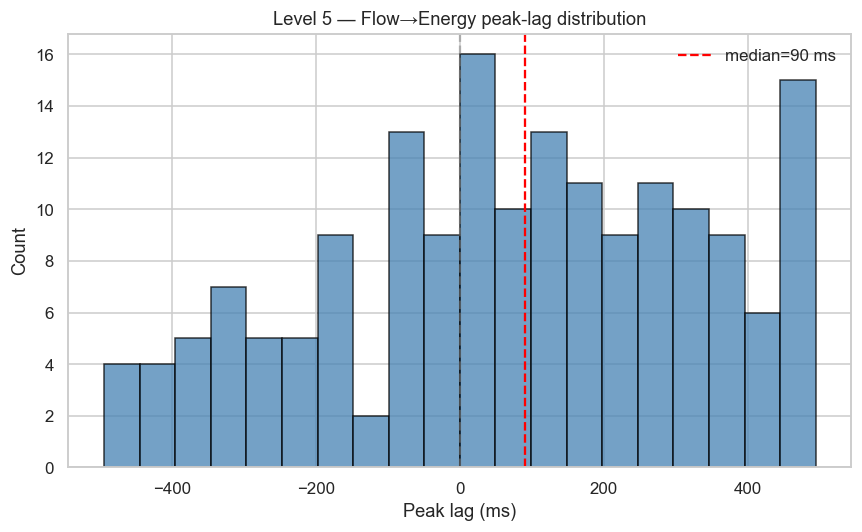

In [14]:

peak_lags = []
for h5 in sus:
    df, meta = PairedFeatureExtractor.load_hdf5(h5)
    v = df[df['voiced']==1.0]
    if len(v) < 50: continue
    _, _, pl, _ = m2.compute_xcorr_lag(v['flow_cw'].values, v['energy'].values, max_lag, fps)
    peak_lags.append(pl*1000)
peak_lags = np.array(peak_lags)
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(peak_lags, bins=20, color='steelblue', alpha=0.75, edgecolor='black')
ax.axvline(0, color='gray', ls='--', alpha=0.5)
ax.axvline(np.median(peak_lags), color='red', ls='--', label=f'median={np.median(peak_lags):.0f} ms')
ax.set_xlabel('Peak lag (ms)'); ax.set_ylabel('Count')
ax.set_title('Level 5 — Flow→Energy peak-lag distribution'); ax.legend(); plt.tight_layout(); plt.show()

> **Observe:** peak lags cluster around 0 (a few frames); the occasional large lag is a recording with weak coupling where the peak is ill-defined — not a real temporal offset.

## Level 6 — Breath-group analysis (connected speech)
The read text (`testo`) is segmented into breath groups at inspiratory peaks of `ΔVcw`; we track how
features evolve from the first to the last breath group.

In [15]:

from scipy.ndimage import uniform_filter1d
from scipy.signal import find_peaks
bg_rows = []
for h5 in [h for h in h5_files if h.stem.endswith('_testo')]:
    df, meta = PairedFeatureExtractor.load_hdf5(h5)
    if len(df) < 200: continue
    dcw = uniform_filter1d(df['delta_vcw'].values, size=20)
    peaks, _ = find_peaks(dcw, distance=100, prominence=0.1)
    if len(peaks) < 2: continue
    for i in range(len(peaks)-1):
        bg = df.iloc[peaks[i]:peaks[i+1]]
        vb = bg[bg['voiced']==1.0]
        if len(bg) < 30 or len(vb) < 10: continue
        bg_rows.append(dict(subject=meta['subject_id'], bg_position=(i+1)/(len(peaks)-1),
            f0_mean=np.nanmean(vb['f0']), energy_mean=vb['energy'].mean(),
            delta_vcw_used=bg['delta_vcw'].iloc[0]-bg['delta_vcw'].iloc[-1],
            flow_cw_mean=bg['flow_cw'].mean(), pct_rc_mean=bg['pct_rc'].mean(),
            duration_sec=len(bg)*0.015))
bg = pd.DataFrame(bg_rows)
print(f"{len(bg)} breath groups from {bg['subject'].nunique()} subjects")

623 breath groups from 38 subjects


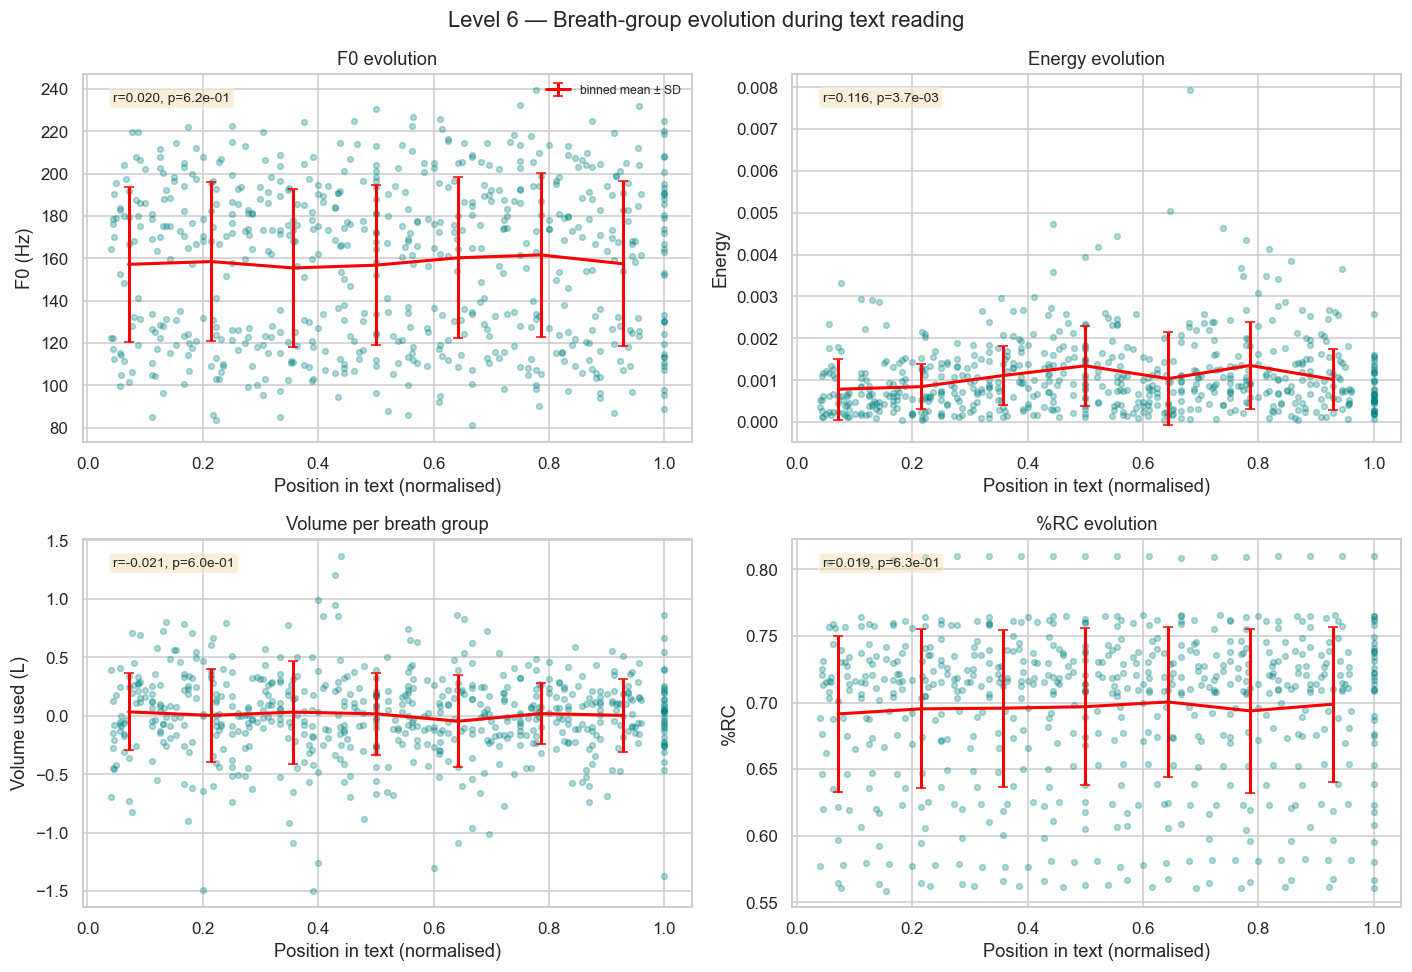

In [16]:

plot_cols = [('f0_mean','F0 (Hz)','F0 evolution'), ('energy_mean','Energy','Energy evolution'),
             ('delta_vcw_used','Volume used (L)','Volume per breath group'),
             ('pct_rc_mean','%RC','%RC evolution')]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
bins = np.linspace(0, 1, 8); centers = (bins[:-1]+bins[1:])/2
for ax, (col, ylab, title) in zip(axes.flat, plot_cols):
    ax.scatter(bg['bg_position'], bg[col], alpha=0.3, s=14, color='teal')
    bg['_b'] = pd.cut(bg['bg_position'], bins, labels=False)
    bm = bg.groupby('_b')[col].agg(['mean','std']).dropna()
    ax.errorbar(centers[:len(bm)], bm['mean'], yerr=bm['std'], color='red', lw=2, capsize=3,
                label='binned mean ± SD')
    v = bg[['bg_position', col]].dropna(); r, p = stats.pearsonr(v['bg_position'], v[col])
    ax.annotate(f'r={r:.3f}, p={p:.1e}', xy=(0.05,0.95), xycoords='axes fraction', va='top',
                fontsize=9, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    ax.set_xlabel('Position in text (normalised)'); ax.set_ylabel(ylab); ax.set_title(title)
axes.flat[0].legend(fontsize=8)
plt.suptitle('Level 6 — Breath-group evolution during text reading'); plt.tight_layout(); plt.show()

> **Observe (connected speech):** within a breath group, F0 and loudness **decline** as the lung empties (declination), tracking the falling `ΔVcw` — the clearest natural audio↔respiratory coupling outside the glide, driven by sub-glottal pressure falling with volume.

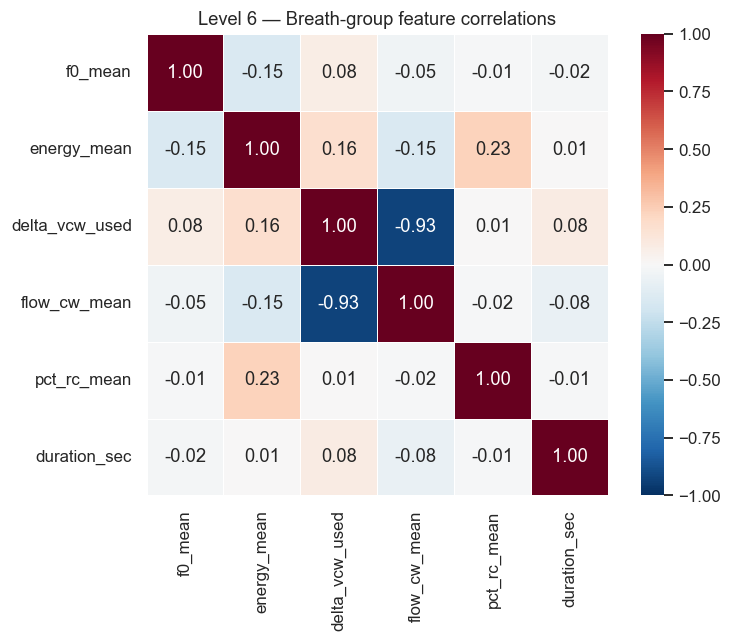

In [17]:

bcols = ['f0_mean','energy_mean','delta_vcw_used','flow_cw_mean','pct_rc_mean','duration_sec']
fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(bg[bcols].dropna().corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title('Level 6 — Breath-group feature correlations'); plt.tight_layout(); plt.show()

> **Observe:** breath-group-level correlations are **stronger** than frame-level ones — aggregating over a breath group averages out frame noise and exposes the declination coupling.

## Level 7 — MFCC ↔ respiratory correlations
For each recording we correlate the first 8 MFCCs with three respiratory targets on voiced frames,
then summarise across the cohort as a heatmap and per-coefficient boxplots.

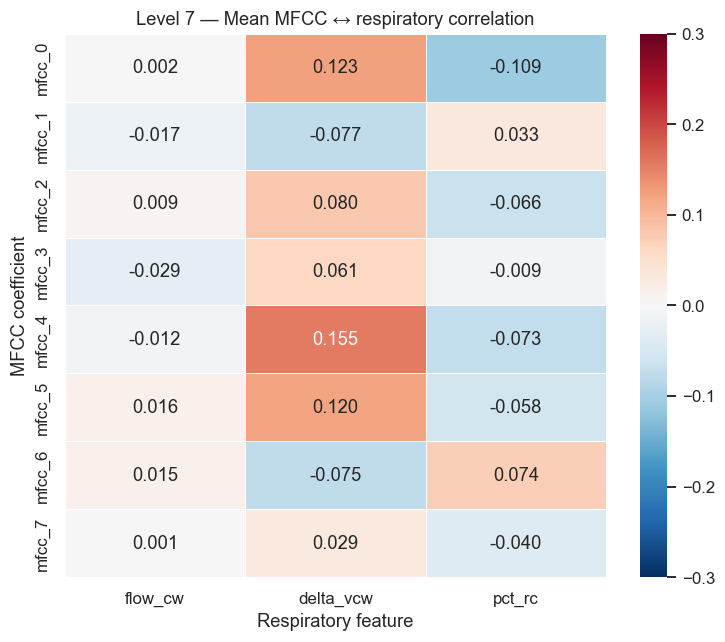

In [18]:

mfcc_rows = []
SAMPLE = h5_files[:150]   # subset for speed; the script uses the full corpus
for h5 in SAMPLE:
    df, meta = PairedFeatureExtractor.load_hdf5(h5)
    v = df[df['voiced']==1.0]
    if len(v) < 30: continue
    tt = 'sustained' if meta.get('task_name') in m2.SUSTAINED_TASKS else 'speech'
    for oep in ['flow_cw','delta_vcw','pct_rc']:
        for i in range(8):
            mc = f'mfcc_{i}'
            vv = v[[mc, oep]].dropna()
            if len(vv) > 20:
                r, p = stats.pearsonr(vv[mc], vv[oep])
                mfcc_rows.append(dict(mfcc=mc, oep_feature=oep, r=r, task_type=tt))
mfcc_df = pd.DataFrame(mfcc_rows)
mfcc_labels = [f'mfcc_{i}' for i in range(8)]
pivot = (mfcc_df.groupby(['mfcc','oep_feature'])['r'].mean().unstack()
         .reindex(index=mfcc_labels, columns=['flow_cw','delta_vcw','pct_rc']))
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdBu_r', center=0, vmin=-0.3, vmax=0.3,
            linewidths=0.5, ax=ax)
ax.set_title('Level 7 — Mean MFCC ↔ respiratory correlation'); ax.set_xlabel('Respiratory feature')
ax.set_ylabel('MFCC coefficient'); plt.tight_layout(); plt.show()

> **Observe:** most MFCCs correlate weakly with respiratory features; the strongest are low-order coefficients (overall energy/tilt), echoing the energy↔volume link rather than adding independent articulatory information.

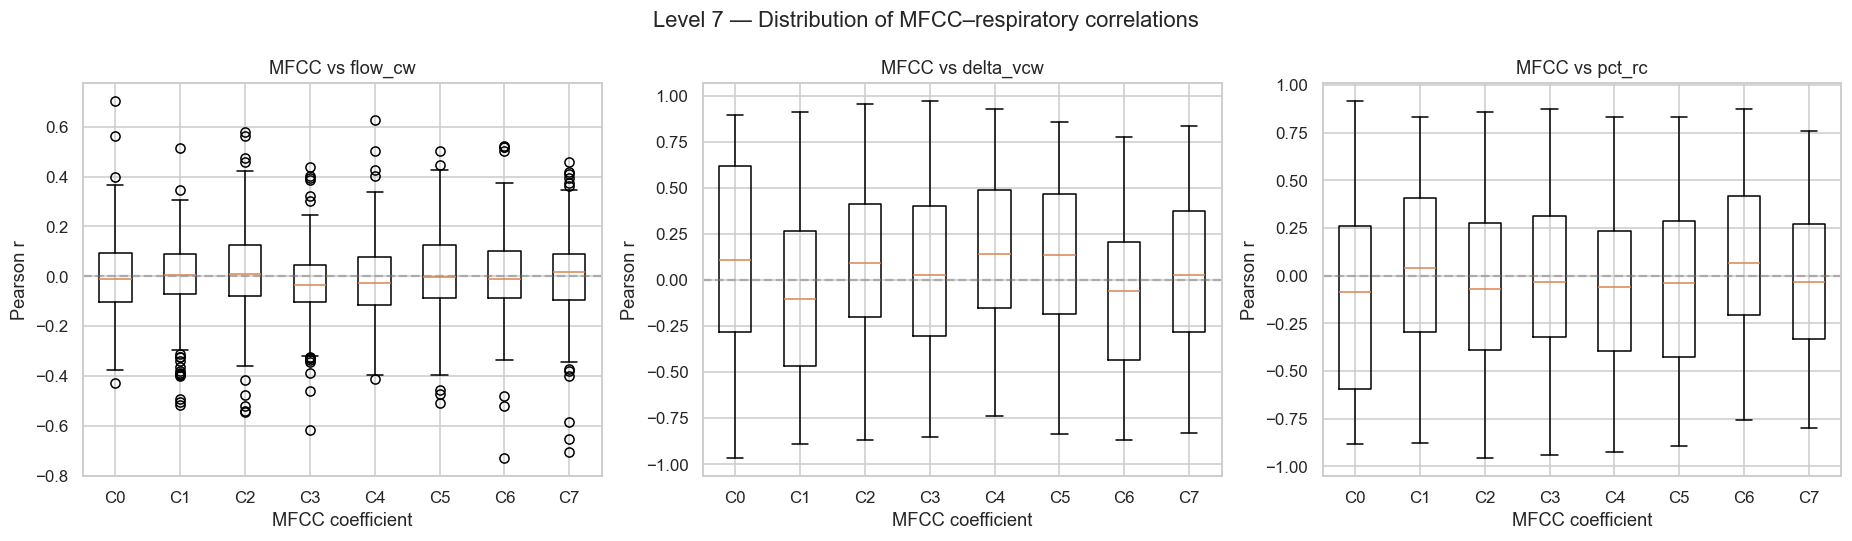

In [19]:

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, oep in zip(axes, ['flow_cw','delta_vcw','pct_rc']):
    sub = mfcc_df[mfcc_df['oep_feature']==oep]
    data = [sub[sub['mfcc']==m]['r'].values for m in mfcc_labels]
    ax.boxplot(data, labels=[m.replace('mfcc_','C') for m in mfcc_labels])
    ax.axhline(0, color='gray', ls='--', alpha=0.5)
    ax.set_ylabel('Pearson r'); ax.set_xlabel('MFCC coefficient'); ax.set_title(f'MFCC vs {oep}')
plt.suptitle('Level 7 — Distribution of MFCC–respiratory correlations'); plt.tight_layout(); plt.show()

> **Observe:** the MFCC↔OEP heatmap is mostly pale (|r|<0.2) — no MFCC is a strong respiratory marker. Spectral *shape* carries little respiratory information beyond what loudness already gives.

## Recap
All seven M2 levels run here on the real 546-recording corpus, reusing `m2_correlation.py`'s own
computation functions. To regenerate the full PDF report instead, run:

```bash
python scripts/m2_correlation.py     # choose "healthy_subjects"
```

Notebook **04** drills into Level&nbsp;3 (FRC crossing) with standardized effect sizes and
demographic stratification.